In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(1,'/Users/sadmin/Documents/MeerFish') # path to MeerFish code
import cosmo
import survey
import model
import fisher

f_tobsloss = 0.5 # fraction of observation time loss

## parameters to include in Fisher forecast:
theta_ids = [\
    #r'$\overline{T}_{\rm HI}$',\
    #r'$b_1$',\
    #r'$b_2$',\
    #r'$b^\phi_1$',\
    #r'$b^\phi_2$',\
    #r'$f$',\
    #r'$\alpha_\perp$',\
    #r'$\alpha_\parallel$',\
    r'$A_{\rm BAO}$',\
    #r'$f_{\rm NL}$'\
    ]

Survey1_arg = 'MK_UHF' # MeerKLASS UHF-band IM survey
Survey2_arg = 'DESI_LRG' # DESI LRG galaxies
t_obs = 800 # total MeerKLASS observation time
A_sky = 4000 # original sky area
A_skyX = 3000 # sky area overlapping with DESI galaxies

### Show BAO wiggles detection approach:

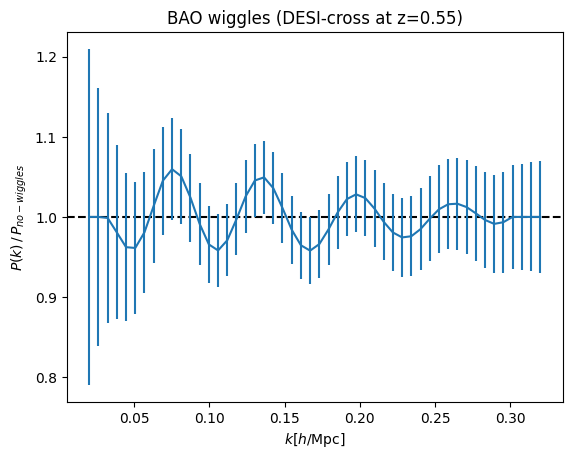

In [17]:


zminzmax = [0.5,0.6]
'''
z,zmin1,zmin2,zmax1,zmax2,A_sky1,A_sky2,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,t_tot,N_dish,sigma_z1,sigma_z2,P_N,nbar = survey.params(Survey1=Survey1_arg,Survey2=Survey2_arg,zminzmax=zminzmax,A_sky1=A_sky,t_tot=t_obs)
surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fg
cosmopars = cosmo.SetCosmology(z=z,return_cosmopars=True) # set initial default cosmology
nuispars = 0,0,0
k_fg = 0
Pmod = cosmo.MatterPk(z)

k = np.linspace(0.02,0.32,50)
ell = 0
P_X = model.P_ell(ell,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_err = model.sigma_ell_error(ell,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_smooth,f_BAO_HI_wb = model.Pk_noBAO(P_X,k)
plt.axhline(1,color='black',ls='--')
plt.errorbar(k,P_X/P_smooth,P_err/P_smooth)
'''

z,zmin1,zmin2,zmax1,zmax2,A_sky1,A_sky2,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,t_tot,N_dish,sigma_z1,sigma_z2,P_N,nbar = survey.params(Survey1=Survey1_arg,Survey2=Survey2_arg,zminzmax=zminzmax,A_sky1=A_sky,t_tot=t_obs)
k_fg = 0
surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fg
cosmopars = cosmo.SetCosmology(z=z,return_cosmopars=True) # set initial default cosmology
nuispars = 0,0,0
Pmod = cosmo.MatterPk(z)

k = np.linspace(0.02,0.32,50)
ell = 0
P_X = model.P_ell(ell,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_err = model.sigma_ell_error(ell,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_smooth,f_BAO_HI_wb = model.Pk_noBAO(P_X,k)
plt.axhline(1,color='black',ls='--')
plt.errorbar(k,P_X/P_smooth,P_err/P_smooth)
plt.xlabel(r'$k [h/{\rm Mpc}]$')
plt.ylabel(r'$P(k)\,/\,P_{no-wiggles}$')
plt.title('BAO wiggles (DESI-cross at z=%s)'%z) 
plt.show()

### Produce SNR estimate for two quoted redshifts:

In [18]:
zs = [0.65,0.8] # central redshifts for each bin
deltaz = 0.1 # redshift width for each bin

for i,z_i in enumerate(zs):
    zminzmax = [z_i-deltaz/2,z_i+deltaz/2] # use default
    z,zmin1,zmin2,zmax1,zmax2,A_sky1,A_sky2,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,t_tot,N_dish,sigma_z1,sigma_z2,P_N,nbar = survey.params(Survey1=Survey1_arg,Survey2=Survey2_arg,zminzmax=zminzmax,A_sky1=A_sky,A_skyX=A_skyX,t_tot=t_obs)
    surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,0
    cosmopars = cosmo.SetCosmology(z=z,return_cosmopars=True) # set initial default cosmology
    nuispars = 0,0,0
    Pmod = cosmo.MatterPk(z)
    k = np.linspace(0.02,0.32,50)
    #ells = [0,2,4]
    ells = [0]

    ### HI auto:
    F = fisher.Matrix_ell(theta_ids,k,Pmod,cosmopars,surveypars,nuispars,ells,tracer='1')
    C = fisher.FisherInverse(F)
    SNR_BAO = 1/np.sqrt(C[0][0])
    print('HI auto ( z =',z,'):',SNR_BAO)

    ### Cross-correlation:    
    F = fisher.Matrix_ell(theta_ids,k,Pmod,cosmopars,surveypars,nuispars,ells,tracer='X')
    C = fisher.FisherInverse(F)
    SNR_BAO = 1/np.sqrt(C[0][0])
    print('Cross ( z =',z,'):',SNR_BAO)


HI auto ( z = 0.65 ): 3.593869152267312
Cross ( z = 0.65 ): 4.529376872257844
HI auto ( z = 0.8 ): 3.0316422336644893
Cross ( z = 0.8 ): 4.211559476205183


### Explore impact from a very simple model of signal loss from foreground cleaning:
Here we assume large-scale radial modes i.e. small $k_\parallel$ modes, are damped due to signal loss caused by our foreground cleaning. We damp the power spectrum with the phenomenlogical model given by
$$P_{\rm damped}(k,\mu) = P_{\rm original}(k,\mu)B_{\rm fg}(k,\mu)$$
where 
$$B_{\rm fg}(k,\mu) = 1 - \exp\Bigg[-\Bigg(\frac{k_\parallel}{k_\parallel^{\rm fg}}\Bigg)\Bigg]$$


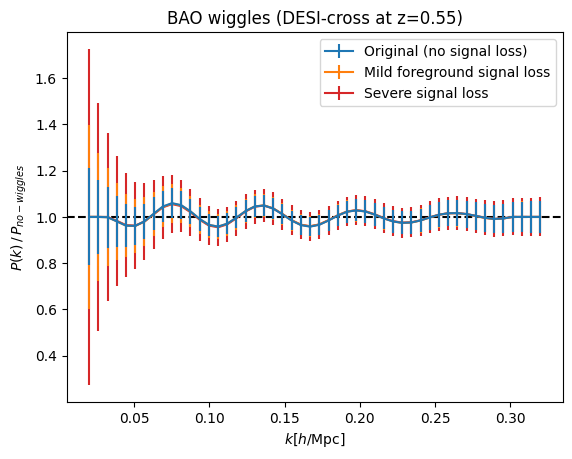

In [15]:

zminzmax = [0.5,0.6]
z,zmin1,zmin2,zmax1,zmax2,A_sky1,A_sky2,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,t_tot,N_dish,sigma_z1,sigma_z2,P_N,nbar = survey.params(Survey1=Survey1_arg,Survey2=Survey2_arg,zminzmax=zminzmax,A_sky1=A_sky,t_tot=t_obs)
cosmopars = cosmo.SetCosmology(z=z,return_cosmopars=True) # set initial default cosmology
nuispars = 0,0,0
plt.axhline(1,color='black',ls='--')

Pmod = cosmo.MatterPk(z)
k = np.linspace(0.02,0.32,50)
ell = 0

k_fg = 0 ## no signal loss (original case)
surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fg
P_X = model.P_ell(ell,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_err = model.sigma_ell_error(ell,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_smooth,f_BAO_HI_wb = model.Pk_noBAO(P_X,k)
plt.errorbar(k,P_X/P_smooth,P_err/P_smooth,label='Original (no signal loss)',zorder=10)

k_fg = 0.05 ## add some damping to power due to signal loss from foreground cleaning
surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fg
P_X = model.P_ell(ell,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_err = model.sigma_ell_error(ell,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_smooth,f_BAO_HI_wb = model.Pk_noBAO(P_X,k)
plt.errorbar(k,P_X/P_smooth,P_err/P_smooth,label='Mild foreground signal loss',color='tab:orange',zorder=9)

k_fg = 0.2 ## add more severe signal loss
surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fg
P_X = model.P_ell(ell,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_err = model.sigma_ell_error(ell,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_smooth,f_BAO_HI_wb = model.Pk_noBAO(P_X,k)
plt.errorbar(k,P_X/P_smooth,P_err/P_smooth,label='Severe signal loss',color='tab:red',zorder=8)

plt.xlabel(r'$k [h/{\rm Mpc}]$')
plt.ylabel(r'$P(k)\,/\,P_{no-wiggles}$')
plt.title('BAO wiggles (DESI-cross at z=%s)'%z) 
plt.legend()
plt.show()

### Look at impact on BAO detection SNR:
This makes results dip below 3$\sigma$ - **hence emphasising the importance of controlling systematics**

In [20]:
zs = [0.65,0.8] # central redshifts for each bin
deltaz = 0.1 # redshift width for each bin

k_fg = 0.2

for i,z_i in enumerate(zs):
    zminzmax = [z_i-deltaz/2,z_i+deltaz/2] # use default
    z,zmin1,zmin2,zmax1,zmax2,A_sky1,A_sky2,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,t_tot,N_dish,sigma_z1,sigma_z2,P_N,nbar = survey.params(Survey1=Survey1_arg,Survey2=Survey2_arg,zminzmax=zminzmax,A_sky1=A_sky,A_skyX=A_skyX,t_tot=t_obs)
    surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fg
    cosmopars = cosmo.SetCosmology(z=z,return_cosmopars=True) # set initial default cosmology
    nuispars = 0,0,0
    Pmod = cosmo.MatterPk(z)
    k = np.linspace(0.02,0.32,50)
    #ells = [0,2,4]
    ells = [0]

    ### HI auto:
    F = fisher.Matrix_ell(theta_ids,k,Pmod,cosmopars,surveypars,nuispars,ells,tracer='1')
    C = fisher.FisherInverse(F)
    SNR_BAO = 1/np.sqrt(C[0][0])
    print('HI auto ( z =',z,'):',SNR_BAO)

    ### Cross-correlation:    
    F = fisher.Matrix_ell(theta_ids,k,Pmod,cosmopars,surveypars,nuispars,ells,tracer='X')
    C = fisher.FisherInverse(F)
    SNR_BAO = 1/np.sqrt(C[0][0])
    print('Cross ( z =',z,'):',SNR_BAO)


HI auto ( z = 0.65 ): 2.939541768220217
Cross ( z = 0.65 ): 2.469181649546925
HI auto ( z = 0.8 ): 2.4821691711732234
Cross ( z = 0.8 ): 2.1164937233433814
